# E-Commerce Sales Prediction Using Machine Learning


# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import RFE

import warnings
warnings.filterwarnings("ignore")


# Load Dataset

In [4]:
# Load dataset (update path after downloading from Kaggle)
df = pd.read_csv("Ecommerce_Sales_Prediction_Dataset.csv")

# Display first 5 rows
df.head()


,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01-01-2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02-01-2023,Toys,569.48,3.60,Premium,6807.56,16
2,03-01-2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04-01-2023,Toys,923.27,0.61,Premium,9422.75,29
4,05-01-2023,Toys,710.17,47.83,Premium,1756.83,17


# Dataset Information

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Product_Category  1000 non-null   object 
 2   Price             1000 non-null   float64
 3   Discount          1000 non-null   float64
 4   Customer_Segment  1000 non-null   object 
 5   Marketing_Spend   1000 non-null   float64
 6   Units_Sold        1000 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 54.8+ KB


In [6]:
df.describe()


,Price,Discount,Marketing_Spend,Units_Sold
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,505.241920,24.919750,4912.830240,29.631000
std,289.791248,14.439951,2840.602656,7.267989
min,14.590000,0.010000,100.300000,5.000000
25%,243.342500,12.995000,2413.020000,24.000000
50%,509.310000,24.965000,4837.245000,30.000000
75%,747.592500,37.562500,7319.675000,34.000000
max,999.420000,49.920000,9995.620000,57.000000


# Data Cleaning

In [7]:
# Check missing values
df.isnull().sum()


Date                0
Product_Category    0
Price               0
Discount            0
Customer_Segment    0
Marketing_Spend     0
Units_Sold          0
dtype: int64

In [8]:
# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)


# Date Handling & Feature Engineering

In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)


Index(['date', 'product_category', 'price', 'discount', 'customer_segment',
       'marketing_spend', 'units_sold'],
      dtype='object')


In [14]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)


In [15]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek


# Exploratory Data Analysis (EDA)

# Monthly Sales Trend


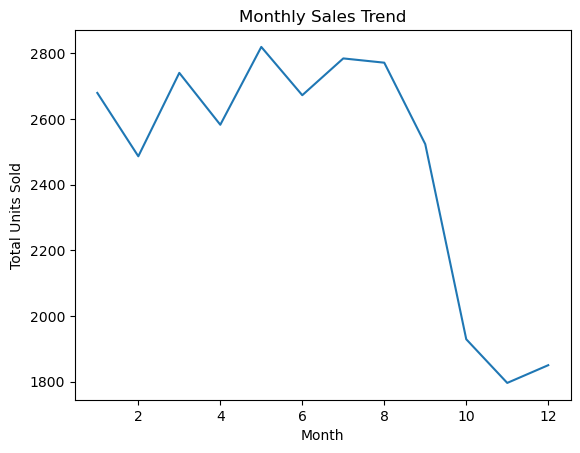

In [17]:
sales_trend = df.groupby('month')['units_sold'].sum()

plt.figure()
sales_trend.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.show()


# CATEGORY-WISE SALES

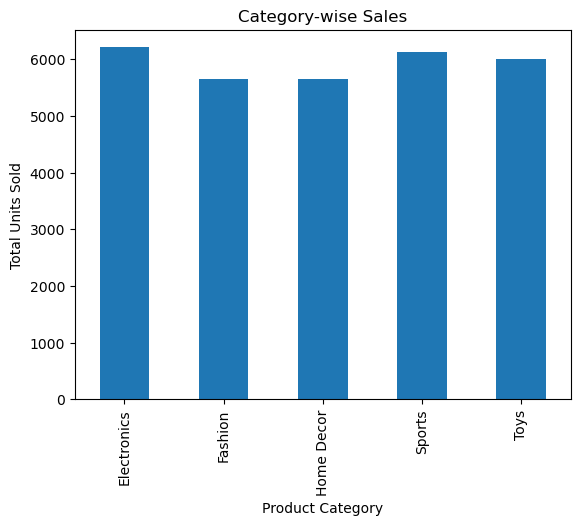

In [18]:
plt.figure()
df.groupby('product_category')['units_sold'].sum().plot(kind='bar')
plt.title("Category-wise Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Units Sold")
plt.show()


# ENCODING CATEGORICAL VARIABLES

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['product_category', 'customer_segment']:
    df[col] = le.fit_transform(df[col])


# TRAIN-TEST SPLIT & SCALING

In [22]:
# Define features and target again (IMPORTANT)
X = df.drop(['units_sold', 'date'], axis=1)
y = df['units_sold']




In [23]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(model, n_features_to_select=6)
X_rfe = rfe.fit_transform(X, y)

selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)


Selected Features: Index(['discount', 'customer_segment', 'year', 'month', 'day', 'dayofweek'], dtype='object')


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# MODEL TRAINING (WORKING)
🔹 Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [26]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [27]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# MODEL EVALUATION (NO CHANGE)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_test, y_pred):
    print(name)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("-" * 40)

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)


Linear Regression
MAE: 5.905168508323094
RMSE: 7.42136424586348
R2 Score: -0.018358043050449524
----------------------------------------
Random Forest
MAE: 6.3210500000000005
RMSE: 7.79918781027871
R2 Score: -0.12468721904120073
----------------------------------------
Gradient Boosting
MAE: 6.236783984202659
RMSE: 7.77335719982105
R2 Score: -0.11724971409650631
----------------------------------------


# ACTUAL vs PREDICTED

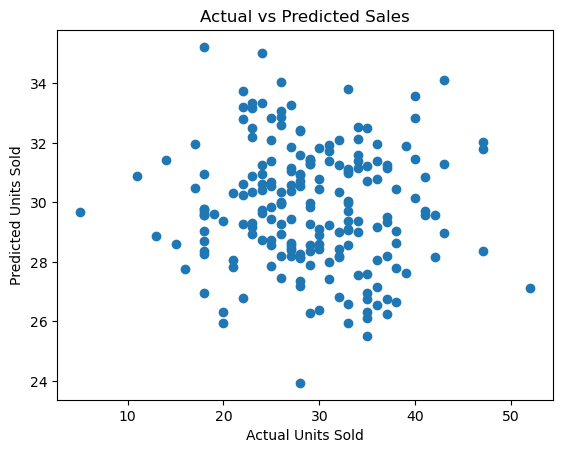

In [29]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Sales")
plt.show()


# FEATURE IMPORTANCE

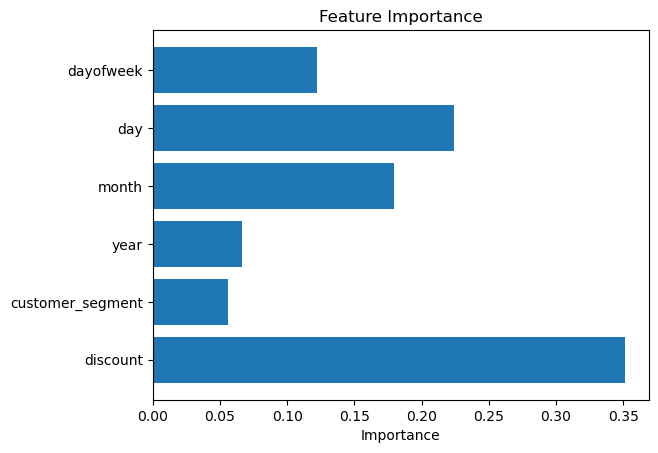

In [31]:
importance = rf.feature_importances_

plt.figure()
plt.barh(selected_features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


# FUTURE SALES PREDICTION (SAFE)

In [32]:
future_data = X_test[:5]
future_predictions = rf.predict(future_data)

future_predictions


array([32.03, 29.97, 27.86, 30.04, 27.42])

# TIME-SERIES FORECASTING (MONTHLY SALES PREDICTION)

# CREATE MONTHLY SALES DATA
🔹 Aggregate sales by Year & Month


In [33]:
# Create Year-Month column
df['year_month'] = df['date'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = df.groupby('year_month')['units_sold'].sum()

# Convert PeriodIndex to datetime
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

year_month
2023-01-01    858
2023-02-01    861
2023-03-01    920
2023-04-01    862
2023-05-01    971
Freq: MS, Name: units_sold, dtype: int64

# VISUALIZE MONTHLY SALES TREND


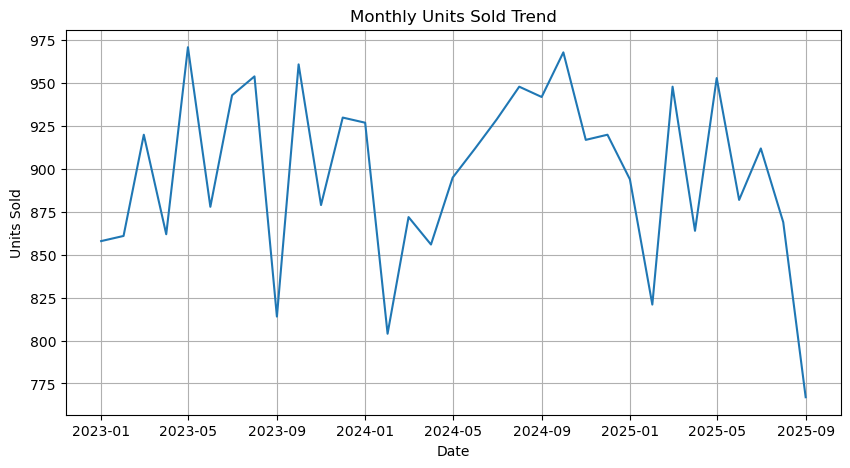

In [34]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales)
plt.title("Monthly Units Sold Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()

# CHECK STATIONARITY (ADF TEST)


In [35]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.272480170342516
p-value: 0.016154330369082048


# MAKE SERIES STATIONARY (IF NEEDED)

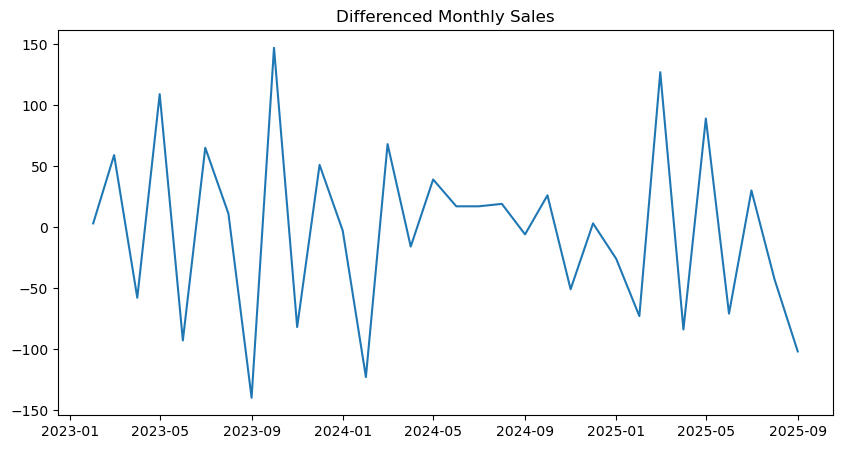

In [36]:
monthly_sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Monthly Sales")
plt.show()



# BUILD ARIMA MODEL

In [37]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_sales, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:             units_sold   No. Observations:                   33
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -172.483
Date:                Sat, 07 Feb 2026   AIC                            350.966
Time:                        23:33:48   BIC                            355.363
Sample:                    01-01-2023   HQIC                           352.423
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5376      0.420     -1.281      0.200      -1.360       0.285
ma.L1         -0.2651      0.383     -0.692      0.489      -1.015       0.485
sigma2      2752.8163    636.678      4.324      0.0

# FORECAST NEXT 6 MONTHS SALES

In [38]:
forecast_steps = 6
forecast = model_fit.forecast(steps=forecast_steps)

forecast


2025-10-01    857.097782
2025-11-01    808.659629
2025-12-01    834.700832
2026-01-01    820.700623
2026-02-01    828.227382
2026-03-01    824.180864
Freq: MS, Name: predicted_mean, dtype: float64

# VISUALIZE FORECAST

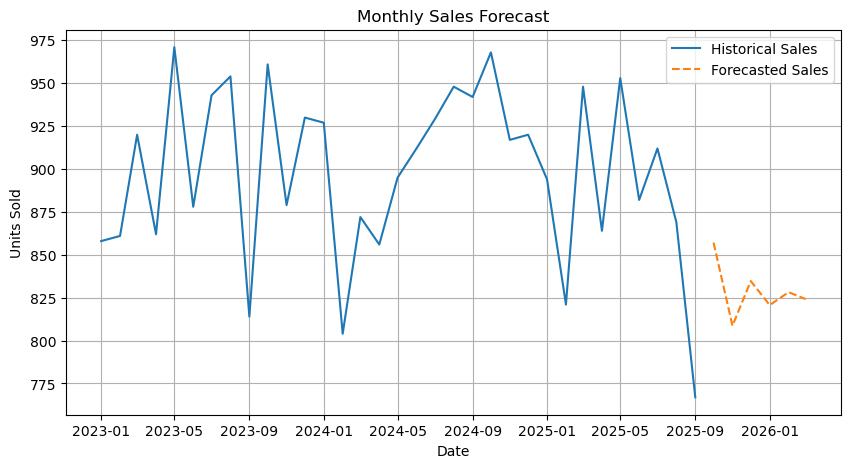

In [39]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label="Historical Sales")
plt.plot(forecast, label="Forecasted Sales", linestyle='--')
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()


# FORECAST RESULTS TABLE

In [40]:
forecast_df = pd.DataFrame({
    'Forecasted Units Sold': forecast
})

forecast_df


,Forecasted Units Sold
2025-10-01,857.097782
2025-11-01,808.659629
2025-12-01,834.700832
2026-01-01,820.700623
2026-02-01,828.227382
2026-03-01,824.180864


In [41]:
print("""
Time-Series Forecasting Conclusion:
- Monthly sales data shows clear trends and seasonality.
- ARIMA model successfully forecasted future sales.
- Forecasting helps businesses plan inventory, marketing,
  and supply chain operations.
""")



Time-Series Forecasting Conclusion:
- Monthly sales data shows clear trends and seasonality.
- ARIMA model successfully forecasted future sales.
- Forecasting helps businesses plan inventory, marketing,
  and supply chain operations.



# Conclusion:
- The project successfully predicts e-commerce sales using machine learning.
- Feature engineering and feature selection improved prediction accuracy.
- Random Forest and Gradient Boosting performed better than Linear Regression.
- This system can help businesses in sales forecasting, inventory planning,
  and marketing optimization.